# Rectified Image Processing for Thermal Landscapes Project
### Nkuhlu
 PB 6/23/22
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Nkuhlu
- The shapefile has 3 columns for treatments: 
    - "Exclosure" which is either "Full"/"Partial"/"Open"
    - "TopoPositi" which is either "Upland"/"Lowland"
    - "Treatment" which is either "Inside"/"Outside"

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# # # Define inputs

img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal')
shp_f = Path('./data/in/Polygons_AD_current/Nkuhlu_polygon.shp')

# Set site/project string for output figures and stats
projstr = 'Nkuhlu'

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set hue order for plotting
exclosure_hues = ["Open", "Partial", "Full"]
topo_hues = ["Upland", "Lowland"]

# # # END USER INPUTS

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# NOTE: The below is discontinued as of 6/22/2022 -
# instead the code goes through all images that overlap multiple treatments
# And removes images based on the above overlap threshold
# Set number of images to consider for final image list 
# nimgs = 1000

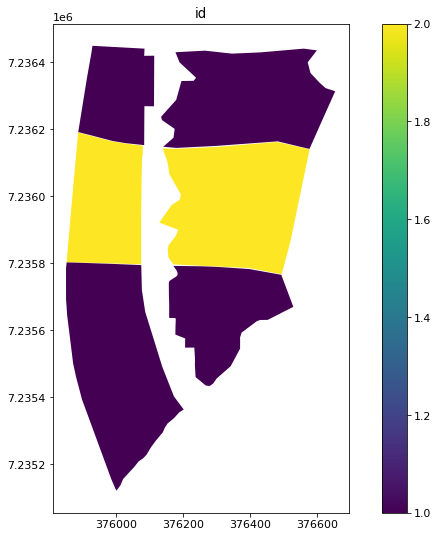

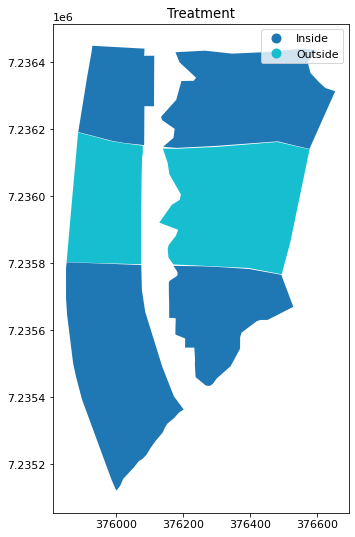

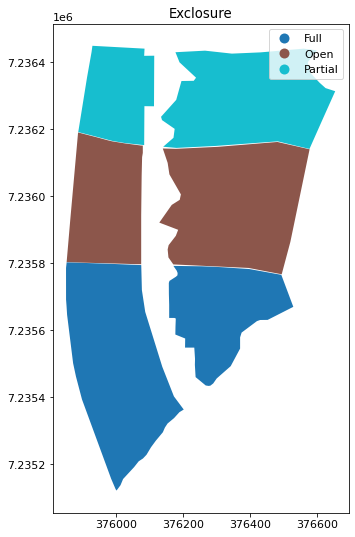

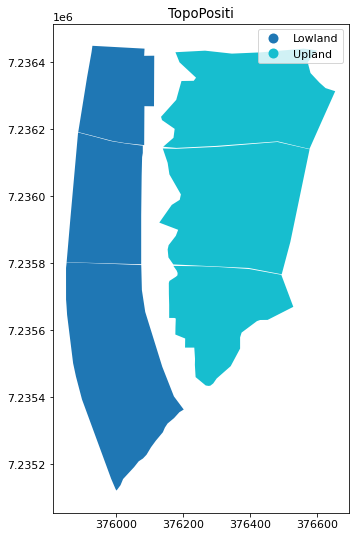

In [2]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    shp.plot(column=c, legend=True)
    plt.title(c)
    plt.savefig(f'./figs/ShapefileFeatures_{c}_{projstr}.png', dpi=300)

In [3]:
# Define a simple evenness function
# compares the difference in coverage 
def evenness(x):
    # Filter for non-zero values
    X = x.loc[x>=0.01]
    # if more than 2:
    if len(X)>=2:
        # test difference between the values
        # This is the mean difference between the values
        # Divided by the sum of the values
        # 1 - is to make it an descending scale (higher values are better)
        # even = 1 - (np.mean(np.abs(np.diff((X)))) / np.sum(X))
        
        # Actually, screw that! Use coeff. of variation
         # NOTE: -1* need to rescale so scale is descending
        even = -1*(np.std(X)/np.mean(X))
    else:
        even = np.nan
    return even

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [4]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    # warnings.simplefilter("ignore")
    warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, feat in zip(shp.index, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)
    

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

<AxesSubplot:>

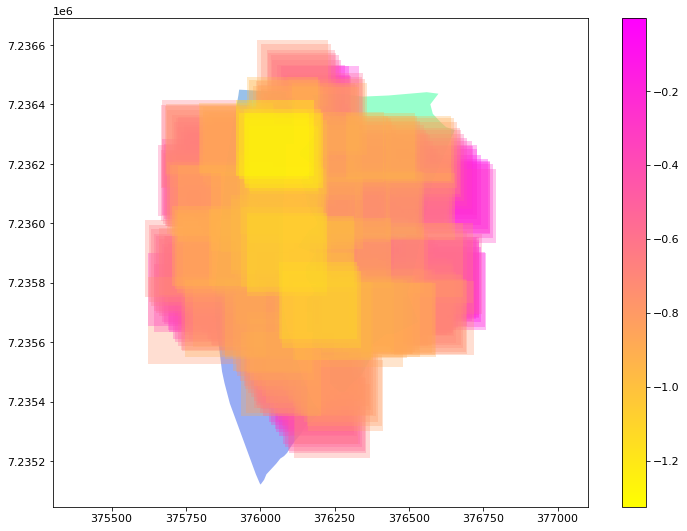

In [5]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Save the cream of the crop in a new df - DISCONTINUED 6/22/2022
# nimgs = len(img_gdf)
# img_gdf_filter = img_gdf.loc[0:(nimgs-1)]

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
img_gdf_filter.plot(ax=ax, alpha=0.3, cmap='spring_r', column='Evenness', legend=True)

### Step 2 - Choose a random set of images that do not overlap with each other

In [6]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Topo':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, [])}

img_dict = {'imgf':[], 'boundary_poly':[],
            'pixels_xr':{}.fromkeys(shp.index, [])}

# Shuffle the images so you img_gdf_maxareaa different one each time
# https://stackoverflow.com/questions/29576430/shuffle-dataframe-rows
# img_gdf_shuffle = img_gdf_maxarea.sample(frac=1).reset_index(drop=True)
# img_gdf_shuffle = img_gdf_maxarea.copy()

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values, img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])   
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Exclosure)
                pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     
                    # Also store number of non-na pixels in each
                    # n = np.sum(np.isnan(pixels.data.flatten()))
                else:
                    pixels=[]
                    n=0
                    
                # Store it in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                img_dict['pixels_xr'][ID].append(pixels)

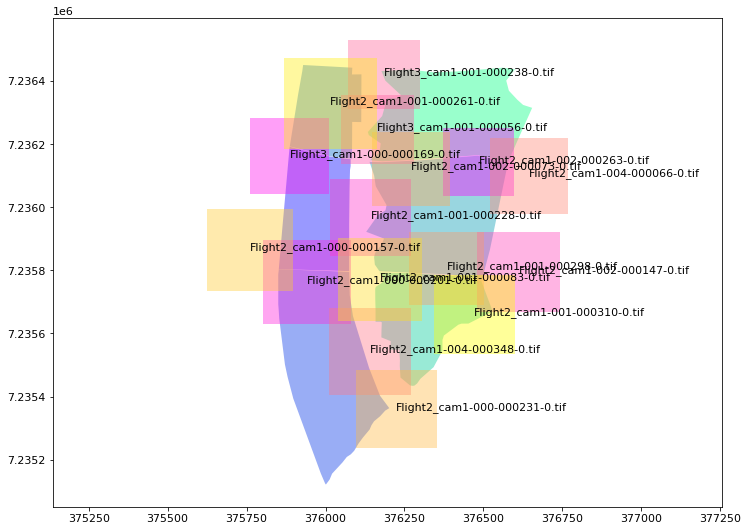

In [7]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s) for s in np.array(img_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)
    
fig.savefig(f'./figs/FinalImageOverlap_{projstr}.png', dpi=300)

In [8]:
# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'Topo':pixel_dict['Topo'][ID][i],
                               'imgf':img})
            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)

## Print Statistics and Plot

In [9]:
nLow = df_pixels.Topo.loc[df_pixels.Topo=='Lowland'].shape[0]
nUp = df_pixels.Topo.loc[df_pixels.Topo=='Upland'].shape[0]
print(f'Lowland: {nLow}, Upland: {nUp}')

nFull = df_pixels.Topo.loc[df_pixels.Exclosure=='Full'].shape[0]
nPart = df_pixels.Topo.loc[df_pixels.Exclosure=='Partial'].shape[0]
nOpen = df_pixels.Topo.loc[df_pixels.Exclosure=='Open'].shape[0]
print(f'Open: {nOpen}, Part: {nPart}, Full: {nFull}')

Lowland: 9797004, Upland: 12255582
Open: 8229606, Part: 6493296, Full: 7329684


In [10]:
df_stats = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
df_stats.to_csv(f'./data/out/{projstr}_stats.csv')

In [12]:
df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).mean()

Temperature
imgf                          Topo    Exclosure             
Flight2_cam1-000-000157-0.tif Lowland Open         38.302765
Flight2_cam1-000-000201-0.tif Lowland Full         35.880363
                                      Open         37.548725
Flight2_cam1-000-000231-0.tif Lowland Full         36.047031
                              Upland  Full         35.857235
Flight2_cam1-001-000083-0.tif Lowland Full         37.589451
                                      Open         41.805843
                              Upland  Full         38.951180
                                      Open         39.108406
Flight2_cam1-001-000228-0.tif Lowland Open         39.539829
                              Upland  Open         39.000179
Flight2_cam1-001-000261-0.tif Lowland Partial      38.679062
Flight2_cam1-001-000298-0.tif Upland  Full         39.582630
                                      Open         39.037399
Flight2_cam1-001-000310-0.tif Upland  Full         38.839561
                                      Open         39.314278
Flight2_cam1-002-000073-0.tif Upland  Open         40.130371
                                      Partial      38.725193
Flight2_cam1-002-000147-0.tif Upland  Full         37.876381
                                      Open         39.045162
Flight2_cam1-002-000263-0.tif Upland  Open         36.010033
                                      Partial      35.450520
Flight2_cam1-004-000066-0.tif Upland  Open         38.002186
Flight2_cam1-004-000348-0.tif Lowland Full         35.526508
                              Upland  Full         36.449425
Flight3_cam1-000-000169-0.tif Lowland Open         40.378792
                                      Partial      40.025738
Flight3_cam1-001-000056-0.tif Lowland Partial      38.138371
                              Upland  Open         40.348961
                                      Partial      39.704590
Flight3_cam1-001-000238-0.tif Lowland Partial      39.780220
                              Upland  Partial      40.112164

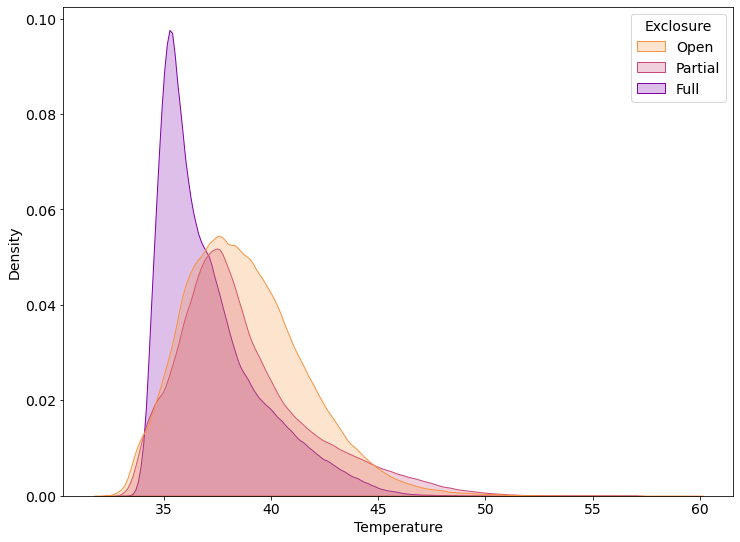

In [13]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)
fig.savefig(f'./figs/KDEplot_Exclosure_{projstr}.png', dpi=300)

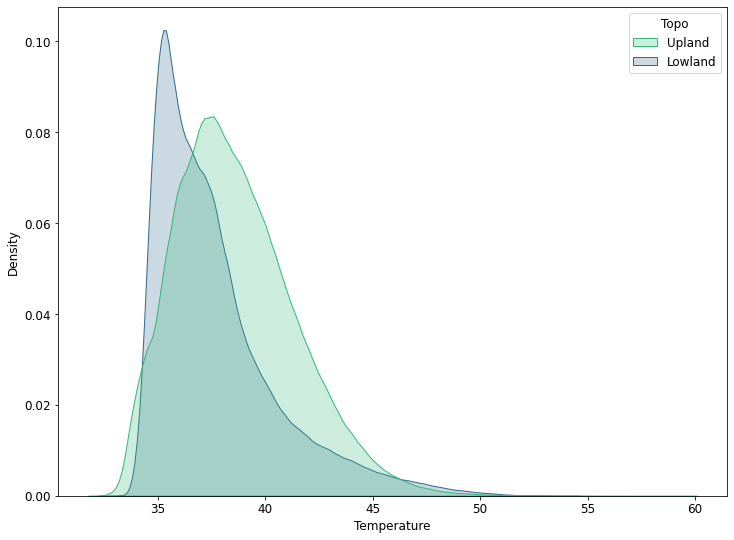

In [14]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Topo', ax=ax, palette='viridis_r',
            fill=True, hue_order=topo_hues)
fig.savefig(f'./figs/KDEplot_Topo_{projstr}.png', dpi=300)

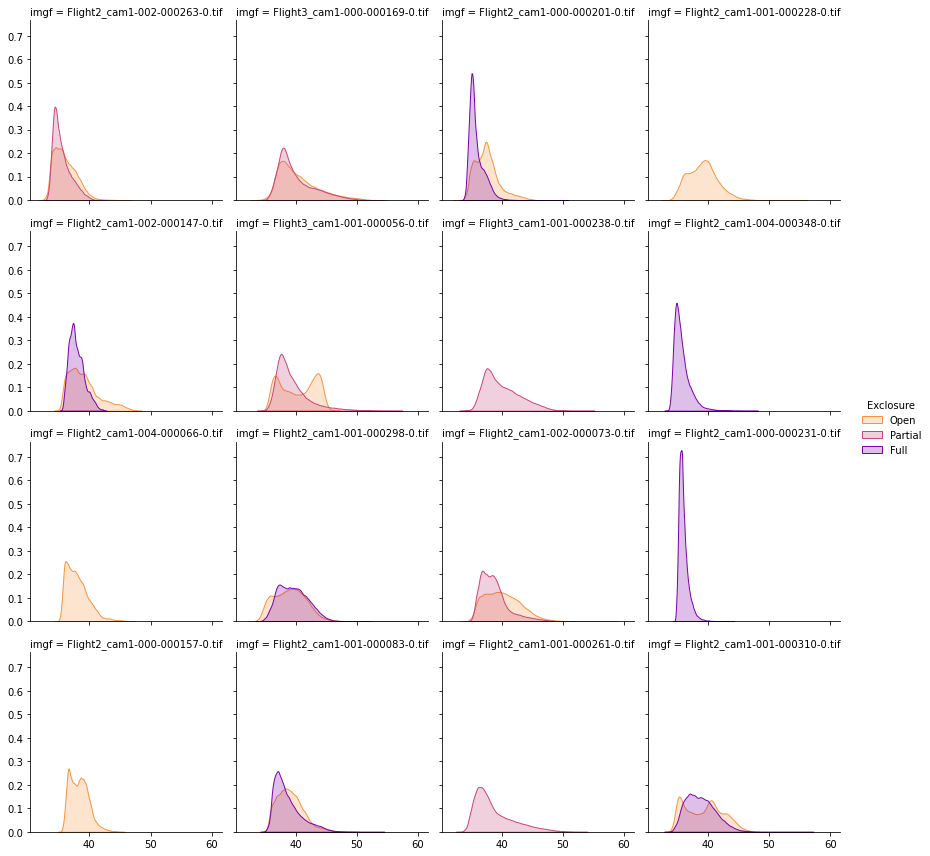

In [15]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()
# ax.legend()


FG.savefig(f'./figs/KDEPlot_Exclosure_FacetGrid_{projstr}_landscape.png', dpi=300)

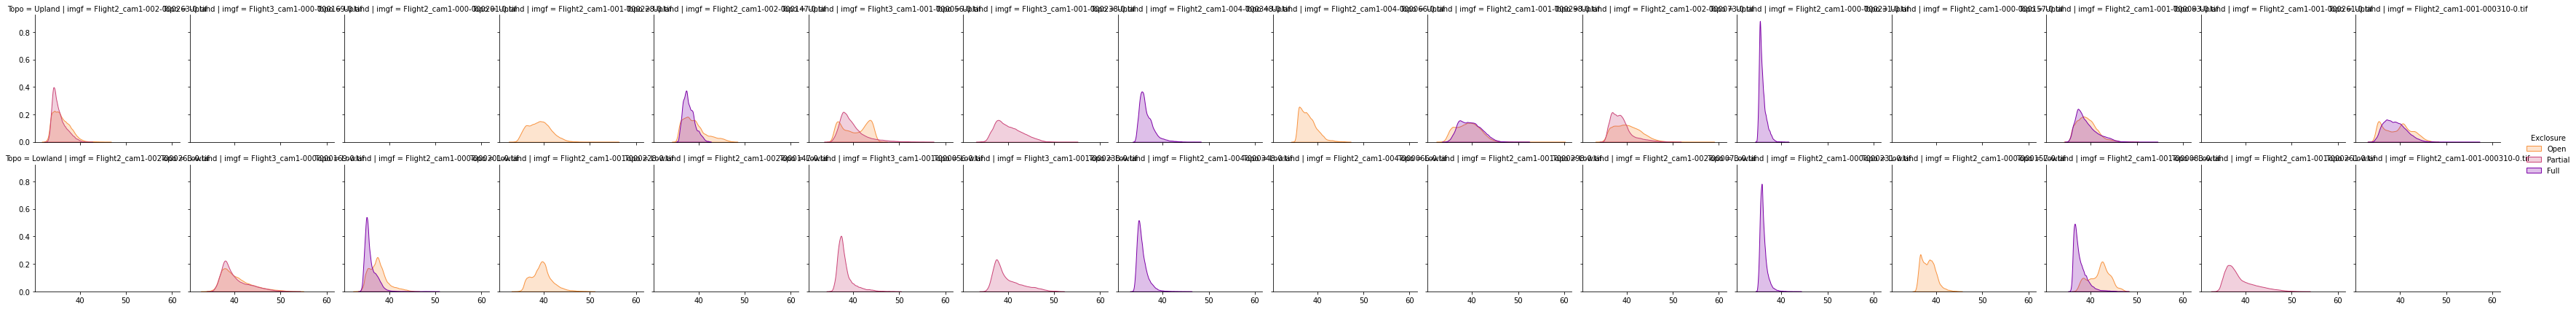

In [16]:
# Use to dataframe to plot KDE plots in a facetgrid
# sns.kdeplot(pixel_dict['pixels_xr'][ID][idx].data.flatten()-273.15, ax=ax)
# FG = sns.FacetGrid(data=df_pixels, col='Exclosure',  row='imgf')
FG = sns.FacetGrid(data=df_pixels, row='Topo', col='imgf',  hue='Exclosure', palette='plasma_r', hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
# ax.legend()

FG.savefig(f'./figs/KDEPlot_Topo_FacetGrid_{projstr}_landscape.png', dpi=300)

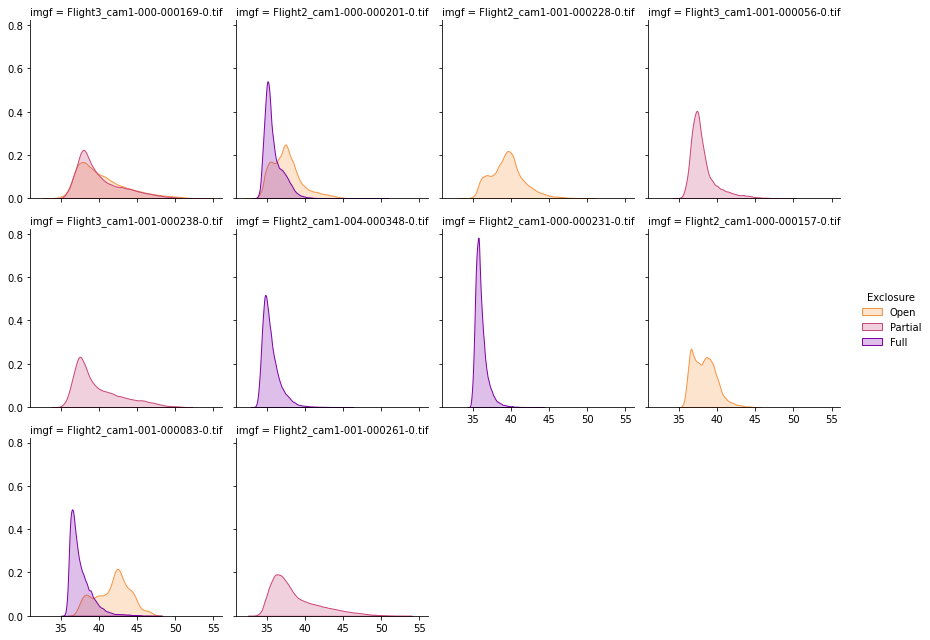

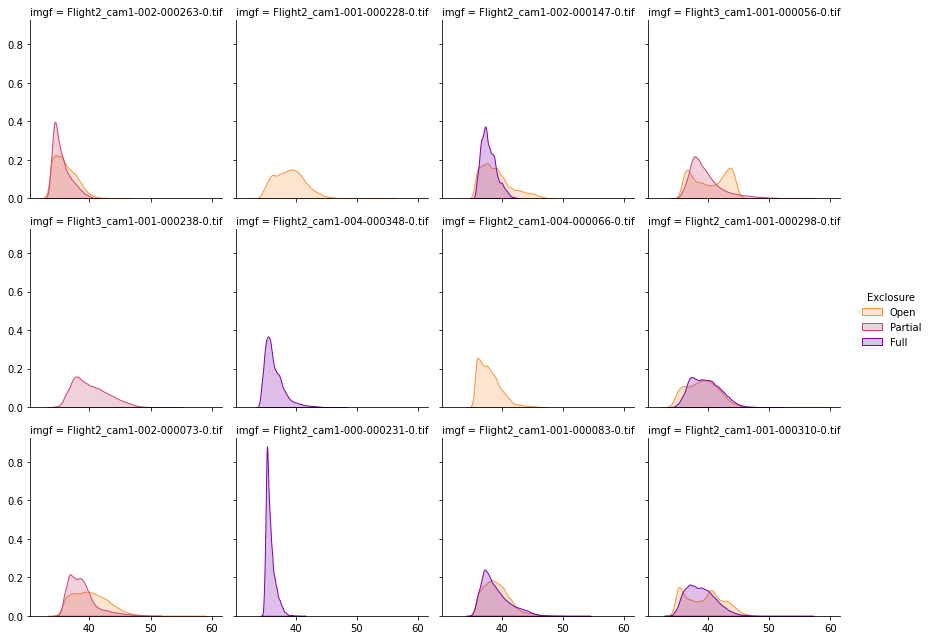

In [17]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Plot Upland and Lowland in seperate Columns
for ul in ['Lowland', 'Upland']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels.loc[df_pixels['Topo']==ul], col='imgf',  hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
    FG.add_legend()
    
    FG.tight_layout()
    # ax.legend()

    FG.savefig(f'./figs/KDEPlot_{ul}_FacetGrid_{projstr}_landscape.png', dpi=300)

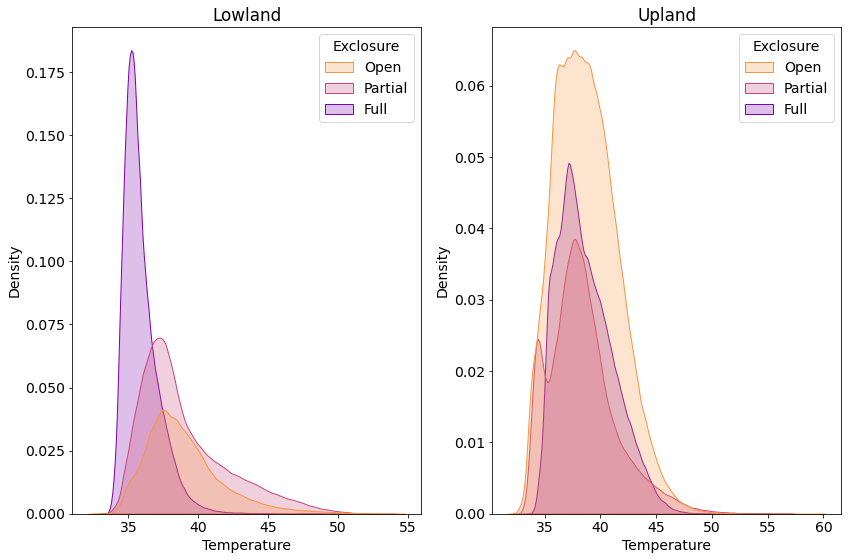

In [18]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(1,2)
# fig.savefig('./figs/KDEplot_Exclosure_Nkuhlu.png', dpi=300)

# Plot Upland and Lowland in seperate Columns
for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):
    
    sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                x='Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                hue_order=exclosure_hues,
                fill=True)
                                   
    ax.set_title(f'{ul}')
    
fig.tight_layout()

fig.savefig(f'./figs/KDEPlot_Exclosure_UpLowSplit_{projstr}.png', dpi=300)